# **<span style="color: #c9a84c;">𓅄 Phase 3 - CNN + Transformer Sequence Model</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

## <span style="color: #f0d080;">Contextual Sign Disambiguation: Moving from Sign Classification to Automated Sentence Translation</span>

<span style="color: #63ace0;">**CS437 / CS5317 / EE414 / EE513 - Deep Learning, Spring 2026**</span>

<span>**Authors:** 𓁐 Maryem Mahmood and Zehra Talat</span>

---

## **<span style="color: #c9a84c;">𓆣 Phase 3 Overview</span>**

<span style="color: #a8c4d8;">This notebook implements **Model 3: CNN + Transformer** building directly on Phase 1's trained ResNet-18 (Glyph2025, 176 classes, 66.72% Top-1).</span>

**𓂋 Key idea:**
Instead of classifying each hieroglyph in isolation (Phase 1), we feed a **sequence** of hieroglyph images through the frozen ResNet-18 backbone, then use a **Transformer Encoder** to learn contextual dependencies. The model learns which neighboring signs disambiguate ambiguous glyphs.

**𓂋 Architecture:**
- Frozen ResNet-18 from Phase 1 (512-dim features per image)
- Linear projection 512 -> 256 + Learned Positional Encoding
- 3-layer Transformer Encoder (4 heads, d_ff=512, GELU)
- Per-position classifier Linear(256 -> NUM_CLASSES)

**𓂋 Sequence construction:**
Sequences are built from the **Franken plate reading order** (filenames encode reading position) using images from the **full Glyph2025 dataset** - giving many more images per class than Franken alone.

**𓂋 Phase 1 baseline to beat:**
| Metric | Value |
|---|---|
| Test Top-1 | 66.72% |
| Test Top-5 | 93.61% |
| Macro F1 | 62.05% |
| Classes | 176 |
| Feature dim | 512 |


# **<span style="color: #c9a84c;">⚙ Section 0 - Environment Setup</span>**

In [5]:
import os, json, re, random, math, warnings
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from sklearn.metrics import f1_score, precision_score, recall_score

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

warnings.filterwarnings('ignore')
random.seed(42); np.random.seed(42); torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')


Device  : cuda
PyTorch : 2.10.0+cu128
GPU     : Tesla T4
VRAM    : 15.6 GB


# **<span style="color: #c9a84c;">𓇋 Section 1 - Load Phase 1 Assets</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">We reload the label maps, split CSVs, and frozen ResNet-18 from Phase 1. Upload the Phase 1 outputs as a Kaggle dataset named **phase1outputs**.</span>


In [6]:
# Paths - upload Phase 1 output zip as Kaggle dataset named 'phase1outputs'
PHASE1_DIR   = Path('/kaggle/input/datasets/maryemmahmood/phase1-output/phase1outputs')
GLYPH_ROOT   = Path('/kaggle/input/datasets/maryemmahmood/glyph2025/Glyph2025')

RESNET_PTH   = PHASE1_DIR / 'resnet18_best.pth'
LABEL_MAP    = PHASE1_DIR / 'label_map.json'
IDX_LABEL    = PHASE1_DIR / 'idx_to_label.json'
TRAIN_CSV    = PHASE1_DIR / 'split_train.csv'
VAL_CSV      = PHASE1_DIR / 'split_val.csv'
TEST_CSV     = PHASE1_DIR / 'split_test.csv'
RESULTS_JSON = PHASE1_DIR / 'phase1_results.json'

for p in [RESNET_PTH, LABEL_MAP, TRAIN_CSV, GLYPH_ROOT]:
    assert p.exists(), f'Not found: {p}'

# Load label maps
with open(LABEL_MAP)  as f: label_to_idx = json.load(f)
with open(IDX_LABEL)  as f: idx_to_label = {int(k): v for k,v in json.load(f).items()}
NUM_CLASSES = len(label_to_idx)

# Load splits
df_train = pd.read_csv(TRAIN_CSV)
df_val   = pd.read_csv(VAL_CSV)
df_test  = pd.read_csv(TEST_CSV)

# Load Phase 1 results
with open(RESULTS_JSON) as f: phase1 = json.load(f)

print(f'NUM_CLASSES  : {NUM_CLASSES}')
print(f'Train images : {len(df_train):,}')
print(f'Val images   : {len(df_val):,}')
print(f'Test images  : {len(df_test):,}')
print()
print('Phase 1 baseline:')
print(f'  Test Top-1 : {phase1["test_top1"]*100:.2f}%')
print(f'  Test Top-5 : {phase1["test_top5"]*100:.2f}%')
print(f'  Macro F1   : {phase1["macro_f1"]*100:.2f}%')


NUM_CLASSES  : 176
Train images : 8,985
Val images   : 1,925
Test images  : 1,926

Phase 1 baseline:
  Test Top-1 : 66.72%
  Test Top-5 : 93.61%
  Macro F1   : 62.05%


In [7]:
# Build label -> image paths from FULL Glyph2025 (not just split subset)
# This gives many more images per class for sequence construction
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

label_to_paths_glyph = defaultdict(list)
for class_dir in sorted(GLYPH_ROOT.iterdir()):
    if class_dir.is_dir():
        label_upper = class_dir.name.upper()
        if label_upper in label_to_idx:
            for img in class_dir.glob('*'):
                if img.suffix.lower() in VALID_EXTS:
                    label_to_paths_glyph[label_upper].append(str(img))

print(f'Classes with images in Glyph2025 : {len(label_to_paths_glyph)}')
total_imgs = sum(len(v) for v in label_to_paths_glyph.values())
print(f'Total images available            : {total_imgs:,}')
print(f'Avg images per class              : {total_imgs/max(len(label_to_paths_glyph),1):.0f}')


Classes with images in Glyph2025 : 176
Total images available            : 12,836
Avg images per class              : 73


In [8]:
# Reload frozen ResNet-18 - architecture matches Phase 1 checkpoint exactly
class ResNetClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        base = models.resnet18(weights=None)
        self.backbone = base
        self.backbone.fc = nn.Identity()
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, num_classes)
        )
        self.feature_dim = 512

    def forward(self, x):
        x = self.backbone(x)
        return self.classifier(x)

    def extract_features(self, x):
        return self.backbone(x)  # (B, 512)

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False


resnet_backbone = ResNetClassifier(NUM_CLASSES).to(DEVICE)
resnet_backbone.load_state_dict(torch.load(RESNET_PTH, map_location=DEVICE))
resnet_backbone.freeze_backbone()
resnet_backbone.eval()

trainable = sum(p.numel() for p in resnet_backbone.parameters() if p.requires_grad)
print(f'ResNet-18 loaded and frozen')
print(f'Trainable params (head only): {trainable:,}')
print(f'Feature dim: {resnet_backbone.feature_dim}')


ResNet-18 loaded and frozen
Trainable params (head only): 90,288
Feature dim: 512


# **<span style="color: #c9a84c;">𓏏 Section 2 - Sequence Dataset Construction</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">We build sequences using **Franken plate reading order** but sample images from the **full Glyph2025 dataset**.</span>

**𓂋 Why this combination?**
- Franken filenames encode real inscription reading order (plate + glyph index)
- Glyph2025 has ~73 images per class on average vs ~20 in Franken alone
- More images per class = more variety in each sequence position = better generalization

**𓂋 Filename format:** `PPNNNN_LABEL.png`
- PP = plate number (03, 05, 07...)
- NNNN = glyph index within plate (reading order)
- LABEL = Gardiner code


In [10]:
# Build sequences from Franken plate reading order
# Use the split CSVs from Phase 1 which already have plate + index columns

def build_sequences(df, label_to_idx, min_len=3, max_len=50):
    """
    Build inscription sequences from Franken plate structure.
    Each plate = one sequence sorted by glyph index (reading order).
    Only keeps glyphs whose label is in our trained vocabulary.
    """
    sequences = []

    # Only use Franken images (have plate/index columns)
    df_franken = df[df['plate'] != -1].copy() if 'plate' in df.columns else pd.DataFrame()

    if df_franken.empty:
        # Fallback: parse from filename
        df_franken = df.copy()
        df_franken['plate'] = df_franken['path'].apply(
            lambda p: int(Path(p).name[:2]) if re.match(r'^\d{6}_', Path(p).name) else -1)
        df_franken['index'] = df_franken['path'].apply(
            lambda p: int(Path(p).name[2:6]) if re.match(r'^\d{6}_', Path(p).name) else -1)
        df_franken = df_franken[df_franken['plate'] != -1]

    for plate, group in df_franken.groupby('plate'):
        group_sorted = group.sort_values('index')
        valid = group_sorted[group_sorted['label'].isin(label_to_idx)]
        if len(valid) < min_len:
            continue
        rows = valid.to_dict('records')
        for start in range(0, len(rows), max_len):
            chunk = rows[start:start + max_len]
            if len(chunk) >= min_len:
                sequences.append(chunk)

    return sequences


train_seqs = build_sequences(df_train, label_to_idx)
val_seqs   = build_sequences(df_val,   label_to_idx)
test_seqs  = build_sequences(df_test,  label_to_idx)

print(f'Train sequences : {len(train_seqs)}')
print(f'Val sequences   : {len(val_seqs)}')
print(f'Test sequences  : {len(test_seqs)}')

if train_seqs:
    lengths = [len(s) for s in train_seqs + val_seqs + test_seqs]
    print(f'Avg length      : {np.mean(lengths):.1f}')
    print(f'Max length      : {max(lengths)}')
    print(f'Min length      : {min(lengths)}')
    print(f'\nExample (first 5 glyphs):')
    for row in train_seqs[0][:5]:
        print(f'  plate={row["plate"]} idx={row["index"]} label={row["label"]}')


Train sequences : 52
Val sequences   : 16
Test sequences  : 15
Avg length      : 41.7
Max length      : 50
Min length      : 4

Example (first 5 glyphs):
  plate=3 idx=0 label=S29
  plate=3 idx=1 label=D58
  plate=3 idx=2 label=N37
  plate=3 idx=3 label=Q3
  plate=3 idx=4 label=X1


In [11]:
# Transforms - same as Phase 1 eval (no augmentation for feature extraction)
IMG_SIZE = 224

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def load_image(path):
    try:
        return Image.open(path).convert('RGB')
    except:
        return Image.new('RGB', (IMG_SIZE, IMG_SIZE), (128, 128, 128))

print('Transforms defined.')


Transforms defined.


In [12]:
# Sequence Dataset - samples images from Glyph2025 for each Gardiner code
MAX_SEQ_LEN = 50
PAD_IDX     = NUM_CLASSES

class GlyphSequenceDataset(Dataset):
    """
    Sequence dataset using Franken reading order + Glyph2025 images.
    Pre-extracts ResNet-18 features to avoid recomputing each epoch.
    """
    def __init__(self, sequences, label_to_idx, label_to_paths,
                 backbone, device, transform, max_len=MAX_SEQ_LEN):
        self.max_len = max_len
        self.samples = []

        backbone.eval()
        print(f'Pre-extracting features for {len(sequences)} sequences...')

        with torch.no_grad():
            for seq in sequences:
                imgs   = []
                labels = []
                for row in seq[:max_len]:
                    lbl   = row['label']
                    # Sample from Glyph2025 images for this label
                    paths = label_to_paths.get(lbl, [])
                    if not paths:
                        # Fallback to original Franken image
                        paths = [row['path']]
                    path = random.choice(paths)
                    img  = load_image(path)
                    imgs.append(transform(img))
                    labels.append(label_to_idx[lbl])

                if not imgs:
                    continue

                img_batch = torch.stack(imgs).to(device)
                feats     = backbone.extract_features(img_batch).cpu()
                self.samples.append((feats, labels))

        print(f'  Done - {len(self.samples)} valid sequences')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        feats, labels = self.samples[idx]
        L        = len(labels)
        pad_len  = self.max_len - L
        feats_p  = torch.cat([feats, torch.zeros(pad_len, feats.shape[1])], dim=0)
        label_t  = torch.tensor(labels + [PAD_IDX]*pad_len, dtype=torch.long)
        mask     = torch.tensor([False]*L + [True]*pad_len)
        return feats_p, label_t, mask, L


print('Building sequence datasets...')
train_seq_ds = GlyphSequenceDataset(train_seqs, label_to_idx, label_to_paths_glyph,
                                     resnet_backbone, DEVICE, eval_tf)
val_seq_ds   = GlyphSequenceDataset(val_seqs,   label_to_idx, label_to_paths_glyph,
                                     resnet_backbone, DEVICE, eval_tf)
test_seq_ds  = GlyphSequenceDataset(test_seqs,  label_to_idx, label_to_paths_glyph,
                                     resnet_backbone, DEVICE, eval_tf)

SEQ_BATCH = 4
train_seq_loader = DataLoader(train_seq_ds, batch_size=SEQ_BATCH, shuffle=True,  num_workers=0)
val_seq_loader   = DataLoader(val_seq_ds,   batch_size=SEQ_BATCH, shuffle=False, num_workers=0)
test_seq_loader  = DataLoader(test_seq_ds,  batch_size=SEQ_BATCH, shuffle=False, num_workers=0)

print(f'\nTrain batches : {len(train_seq_loader)}')
print(f'Val batches   : {len(val_seq_loader)}')
print(f'Test batches  : {len(test_seq_loader)}')


Building sequence datasets...
Pre-extracting features for 52 sequences...
  Done - 52 valid sequences
Pre-extracting features for 16 sequences...
  Done - 16 valid sequences
Pre-extracting features for 15 sequences...
  Done - 15 valid sequences

Train batches : 13
Val batches   : 4
Test batches  : 4


# **<span style="color: #c9a84c;">𓊹 Section 3 - Transformer Architecture</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

| Parameter | Value | Rationale |
|---|---|---|
| d_model | 256 | Small enough for limited sequence data |
| num_heads | 4 | 256/4 = 64 dim per head |
| num_layers | 3 | Deeper risks overfitting on small corpus |
| d_ff | 512 | Standard 2x d_model |
| dropout | 0.1 | Regularisation on small data |
| max_seq_len | 50 | Longest Franken inscription |
| positional encoding | Learned (nn.Embedding) | Better than sinusoidal for fixed sequences |
| CNN backbone | Frozen ResNet-18 (512-dim) | Transfer features from Phase 1 |


In [13]:
class HieroglyphTransformer(nn.Module):
    """
    CNN + Transformer for hieroglyph sequence labeling.
    Input:  (B, N, 512) ResNet-18 features
    Output: (B, N, NUM_CLASSES) per-position logits
    """
    def __init__(self, num_classes, feat_dim=512, d_model=256,
                 num_heads=4, num_layers=3, d_ff=512,
                 dropout=0.1, max_len=MAX_SEQ_LEN):
        super().__init__()
        self.input_proj = nn.Linear(feat_dim, d_model)
        self.pos_emb    = nn.Embedding(max_len, d_model)
        self.dropout    = nn.Dropout(dropout)
        encoder_layer   = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=num_heads,
            dim_feedforward=d_ff, dropout=dropout,
            activation='gelu', batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier  = nn.Linear(d_model, num_classes)
        nn.init.xavier_uniform_(self.input_proj.weight)
        nn.init.xavier_uniform_(self.classifier.weight)

    def forward(self, feats, src_key_padding_mask=None):
        B, N, _ = feats.shape
        x   = self.input_proj(feats)
        pos = torch.arange(N, device=feats.device).unsqueeze(0)
        x   = self.dropout(x + self.pos_emb(pos))
        x   = self.transformer(x, src_key_padding_mask=src_key_padding_mask)
        return self.classifier(x)


transformer = HieroglyphTransformer(NUM_CLASSES).to(DEVICE)
new_params  = sum(p.numel() for p in transformer.parameters())
print(f'Model        : CNN + Transformer')
print(f'Backbone     : Frozen ResNet-18 (512-dim, Phase 1)')
print(f'New params   : {new_params:,}')
print(f'd_model      : 256')
print(f'num_heads    : 4')
print(f'num_layers   : 3')
print(f'max_seq_len  : {MAX_SEQ_LEN}')


Model        : CNN + Transformer
Backbone     : Frozen ResNet-18 (512-dim, Phase 1)
New params   : 1,770,672
d_model      : 256
num_heads    : 4
num_layers   : 3
max_seq_len  : 50


# **<span style="color: #c9a84c;">📈 Section 4 - Training</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">Training only the projection layer, transformer, and classifier head. ResNet-18 backbone is frozen throughout.</span>


In [14]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = correct = total = 0
    for feats, labels, mask, lengths in loader:
        feats  = feats.to(device)
        labels = labels.to(device)
        mask   = mask.to(device)
        optimizer.zero_grad()
        logits = model(feats, src_key_padding_mask=mask)
        B, N, C = logits.shape
        valid   = ~mask.view(B*N)
        loss    = criterion(logits.view(B*N, C)[valid], labels.view(B*N)[valid])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * valid.sum().item()
        preds       = logits.view(B*N, C)[valid].argmax(1)
        correct    += (preds == labels.view(B*N)[valid]).sum().item()
        total      += valid.sum().item()
    return total_loss/total, correct/total


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = correct = total = 0
    for feats, labels, mask, lengths in loader:
        feats  = feats.to(device)
        labels = labels.to(device)
        mask   = mask.to(device)
        logits = model(feats, src_key_padding_mask=mask)
        B, N, C = logits.shape
        valid   = ~mask.view(B*N)
        loss    = criterion(logits.view(B*N, C)[valid], labels.view(B*N)[valid])
        total_loss += loss.item() * valid.sum().item()
        preds       = logits.view(B*N, C)[valid].argmax(1)
        correct    += (preds == labels.view(B*N)[valid]).sum().item()
        total      += valid.sum().item()
    return total_loss/total, correct/total

print('Training utilities defined.')


Training utilities defined.


In [15]:
class WarmupCosine:
    def __init__(self, optimizer, warmup_eps, total_eps, base_lr):
        self.opt = optimizer; self.wu = warmup_eps
        self.total = total_eps; self.lr = base_lr; self.ep = 0
    def step(self):
        self.ep += 1
        ep = self.ep
        if ep <= self.wu:
            lr = self.lr * ep / self.wu
        else:
            progress = (ep - self.wu) / (self.total - self.wu)
            lr = self.lr * 0.5 * (1 + math.cos(math.pi * progress))
        for g in self.opt.param_groups:
            g['lr'] = lr
        return lr


TR_EPOCHS    = 40
TR_PATIENCE  = 10
TR_LR        = 5e-4
TR_WD        = 0.01
WARMUP_EPS   = 5

criterion_tr = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)
optimizer_tr = optim.AdamW(transformer.parameters(), lr=TR_LR, weight_decay=TR_WD)
scheduler_tr = WarmupCosine(optimizer_tr, WARMUP_EPS, TR_EPOCHS, TR_LR)

history_tr   = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'lr':[]}
best_val_tr  = 0.0
best_wts_tr  = None
patience_tr  = 0

print(f'Transformer Training | {NUM_CLASSES} classes | Device: {DEVICE}')
print(f'Epochs: {TR_EPOCHS} | LR: {TR_LR} | Batch: {SEQ_BATCH} | Patience: {TR_PATIENCE}')
print(f'Warmup: {WARMUP_EPS} eps | Label smoothing: 0.1')
print()
print(f'{"Ep":>4} {"TrLoss":>9} {"TrAcc%":>8} {"VaLoss":>9} {"VaAcc%":>8} {"Best%":>8} {"LR":>10}')
print('-' * 65)

for ep in range(1, TR_EPOCHS + 1):
    lr     = scheduler_tr.step()
    tr_l, tr_a = train_epoch(transformer, train_seq_loader, optimizer_tr, criterion_tr, DEVICE)
    va_l, va_a = eval_epoch(transformer,  val_seq_loader,   criterion_tr, DEVICE)

    history_tr['train_loss'].append(tr_l); history_tr['train_acc'].append(tr_a)
    history_tr['val_loss'].append(va_l);   history_tr['val_acc'].append(va_a)
    history_tr['lr'].append(lr)

    improved = va_a > best_val_tr
    if improved:
        best_val_tr = va_a
        best_wts_tr = {k: v.clone() for k, v in transformer.state_dict().items()}
        patience_tr = 0
    else:
        patience_tr += 1

    marker = ' ★' if improved else ''
    print(f'{ep:>4} {tr_l:>9.4f} {tr_a*100:>8.2f} {va_l:>9.4f} '
          f'{va_a*100:>8.2f} {best_val_tr*100:>8.2f} {lr:>10.2e}{marker}')

    if patience_tr >= TR_PATIENCE:
        print(f'\nEarly stopping at epoch {ep}')
        break

print(f'\nBest Val Accuracy: {best_val_tr*100:.2f}%')


Transformer Training | 176 classes | Device: cuda
Epochs: 40 | LR: 0.0005 | Batch: 4 | Patience: 10
Warmup: 5 eps | Label smoothing: 0.1

  Ep    TrLoss   TrAcc%    VaLoss   VaAcc%    Best%         LR
-----------------------------------------------------------------
   1    4.5926    11.76    3.9579    23.13    23.13   1.00e-04 ★
   2    3.7473    25.13    3.4505    31.72    31.72   2.00e-04 ★
   3    3.0862    40.94    2.8052    49.44    49.44   3.00e-04 ★
   4    2.4934    56.09    2.3857    57.09    57.09   4.00e-04 ★
   5    2.0629    64.63    2.1174    64.37    64.37   5.00e-04 ★
   6    1.7425    73.79    1.9851    68.28    68.28   4.99e-04 ★
   7    1.5182    81.02    1.9619    67.16    68.28   4.96e-04
   8    1.3360    87.87    1.8845    68.66    68.66   4.91e-04 ★
   9    1.2191    92.36    1.9189    70.15    70.15   4.84e-04 ★
  10    1.1252    95.91    1.8993    71.64    71.64   4.75e-04 ★
  11    1.0649    97.90    1.9176    71.27    71.64   4.65e-04
  12    1.0258    98.6

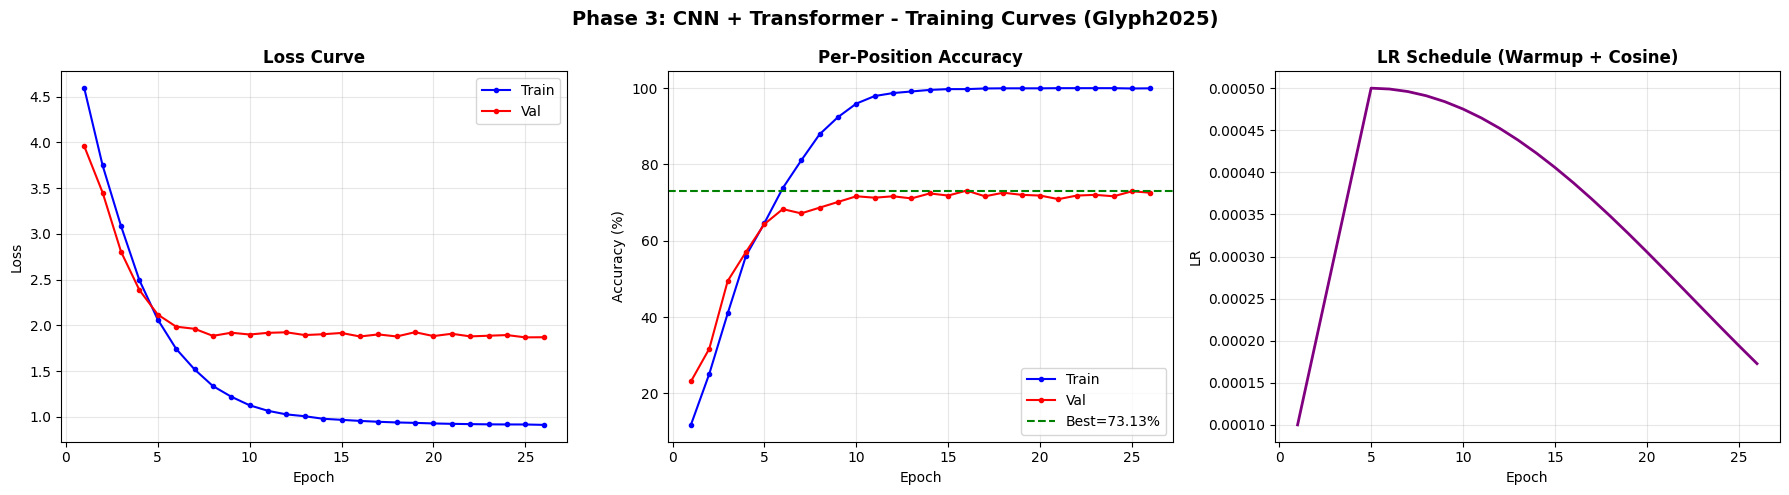

In [16]:
# Learning curves
epochs = range(1, len(history_tr['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs, history_tr['train_loss'], 'b-o', ms=3, label='Train')
axes[0].plot(epochs, history_tr['val_loss'],   'r-o', ms=3, label='Val')
axes[0].set_title('Loss Curve', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, [a*100 for a in history_tr['train_acc']], 'b-o', ms=3, label='Train')
axes[1].plot(epochs, [a*100 for a in history_tr['val_acc']],   'r-o', ms=3, label='Val')
axes[1].axhline(best_val_tr*100, color='green', linestyle='--',
                label=f'Best={best_val_tr*100:.2f}%')
axes[1].set_title('Per-Position Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs, history_tr['lr'], color='purple', lw=2)
axes[2].set_title('LR Schedule (Warmup + Cosine)', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
axes[2].grid(alpha=0.3)

plt.suptitle('Phase 3: CNN + Transformer - Training Curves (Glyph2025)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('transformer_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


# **<span style="color: #c9a84c;">𓏏 Section 5 - Evaluation & Metrics</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">


In [17]:
transformer.load_state_dict(best_wts_tr)
transformer.eval()

all_preds  = []
all_labels = []
seq_correct= 0
seq_total  = 0

with torch.no_grad():
    for feats, labels, mask, lengths in test_seq_loader:
        feats  = feats.to(DEVICE)
        labels = labels.to(DEVICE)
        mask   = mask.to(DEVICE)
        logits = transformer(feats, src_key_padding_mask=mask)
        preds  = logits.argmax(-1)
        B = feats.size(0)
        for i in range(B):
            L = lengths[i].item()
            pred_seq = preds[i, :L].cpu().tolist()
            true_seq = labels[i, :L].cpu().tolist()
            all_preds.extend(pred_seq)
            all_labels.extend(true_seq)
            seq_total  += 1
            if pred_seq == true_seq:
                seq_correct += 1

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

pos_acc     = (all_preds == all_labels).mean()
seq_acc     = seq_correct / max(seq_total, 1)
macro_f1    = f1_score(all_labels, all_preds, average='macro',    zero_division=0)
weighted_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
macro_prec  = precision_score(all_labels, all_preds, average='macro', zero_division=0)
macro_rec   = recall_score(all_labels, all_preds,    average='macro', zero_division=0)

print('=' * 62)
print('  PHASE 3: CNN + TRANSFORMER - FINAL TEST RESULTS')
print('  Dataset: Glyph2025 | Backbone: ResNet-18 (frozen)')
print('=' * 62)
print(f'  Per-Position Accuracy : {pos_acc*100:.2f}%')
print(f'  Sequence Accuracy     : {seq_acc*100:.2f}%')
print(f'  Macro Precision       : {macro_prec*100:.2f}%')
print(f'  Macro Recall          : {macro_rec*100:.2f}%')
print(f'  Macro F1-Score        : {macro_f1*100:.2f}%')
print(f'  Weighted F1-Score     : {weighted_f1*100:.2f}%')
print('=' * 62)
print(f'\nPhase 1 baseline    : {phase1["test_top1"]*100:.2f}% Top-1 (isolated)')
print(f'Phase 3 per-pos acc : {pos_acc*100:.2f}%')
print(f'Delta               : {(pos_acc - phase1["test_top1"])*100:+.2f}% vs Phase 1')

torch.save(best_wts_tr, 'transformer_best.pth')
print('\nCheckpoint saved: transformer_best.pth')


  PHASE 3: CNN + TRANSFORMER - FINAL TEST RESULTS
  Dataset: Glyph2025 | Backbone: ResNet-18 (frozen)
  Per-Position Accuracy : 73.51%
  Sequence Accuracy     : 0.00%
  Macro Precision       : 51.09%
  Macro Recall          : 52.31%
  Macro F1-Score        : 49.90%
  Weighted F1-Score     : 71.07%

Phase 1 baseline    : 66.72% Top-1 (isolated)
Phase 3 per-pos acc : 73.51%
Delta               : +6.79% vs Phase 1

Checkpoint saved: transformer_best.pth


# **<span style="color: #c9a84c;">𓂀 Section 6 - Attention Visualisation</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">Which positions does the transformer attend to when predicting each sign? Strong off-diagonal attention means the model uses context - not just the current image.</span>


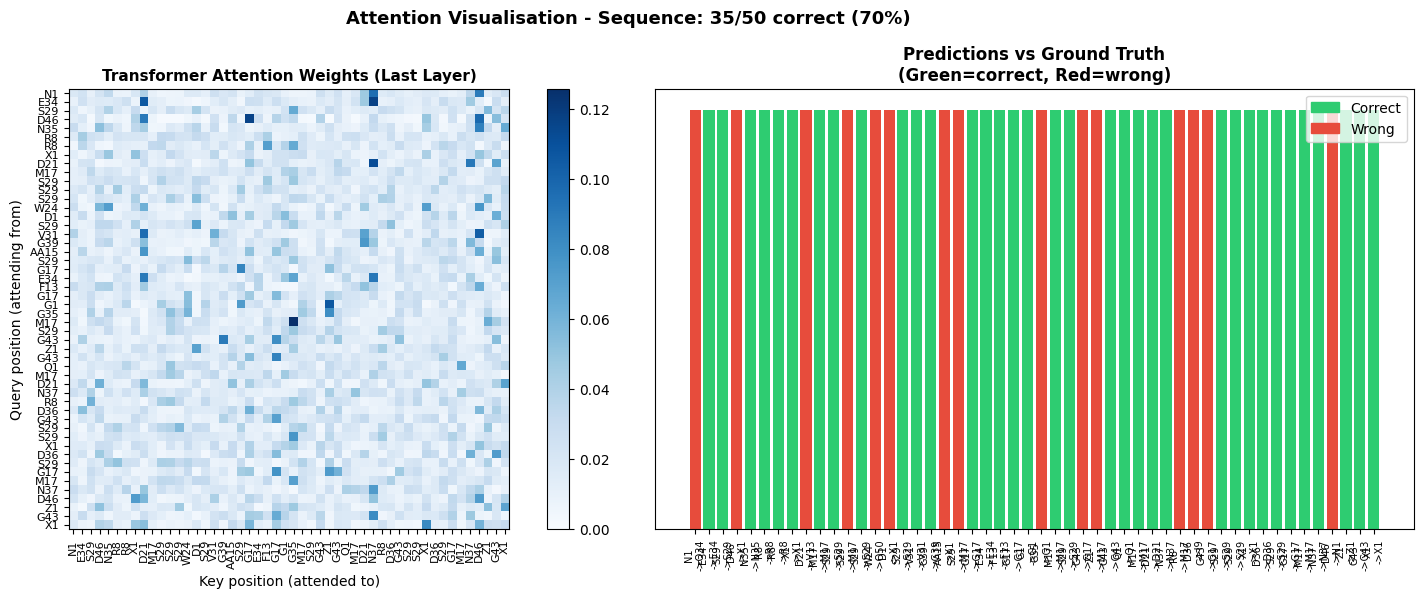

In [18]:
class TransformerWithAttn(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.last_attn = None

    def forward(self, feats, src_key_padding_mask=None):
        x = self.model.input_proj(feats)
        B, N, _ = x.shape
        pos = torch.arange(N, device=feats.device).unsqueeze(0)
        x = self.model.dropout(x + self.model.pos_emb(pos))
        for i, layer in enumerate(self.model.transformer.layers):
            attn_out, attn_w = layer.self_attn(
                x, x, x,
                key_padding_mask=src_key_padding_mask,
                need_weights=True, average_attn_weights=True
            )
            if i == len(self.model.transformer.layers) - 1:
                self.last_attn = attn_w.detach().cpu()
            x2 = layer.norm1(x + layer.dropout1(attn_out))
            x  = layer.norm2(x2 + layer.dropout2(
                layer.linear2(layer.dropout(layer.activation(layer.linear1(x2))))))
        return self.model.classifier(x)


attn_model = TransformerWithAttn(transformer).to(DEVICE)
attn_model.eval()

feats_ex, labels_ex, mask_ex, lengths_ex = next(iter(test_seq_loader))
feats_ex = feats_ex.to(DEVICE); mask_ex = mask_ex.to(DEVICE)

with torch.no_grad():
    logits_ex = attn_model(feats_ex, src_key_padding_mask=mask_ex)

L_ex      = lengths_ex[0].item()
attn      = attn_model.last_attn[0, :L_ex, :L_ex].numpy()
preds_ex  = logits_ex[0, :L_ex].argmax(-1).cpu().numpy()
labels_ex_= labels_ex[0, :L_ex].numpy()
true_names= [idx_to_label.get(int(labels_ex_[i]), '?') for i in range(L_ex)]
pred_names= [idx_to_label.get(int(preds_ex[i]),   '?') for i in range(L_ex)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im = axes[0].imshow(attn, cmap='Blues', vmin=0)
axes[0].set_title('Transformer Attention Weights (Last Layer)',
                  fontweight='bold', fontsize=11)
axes[0].set_xlabel('Key position (attended to)')
axes[0].set_ylabel('Query position (attending from)')
axes[0].set_xticks(range(L_ex)); axes[0].set_xticklabels(true_names, rotation=90, fontsize=8)
axes[0].set_yticks(range(L_ex)); axes[0].set_yticklabels(true_names, fontsize=8)
plt.colorbar(im, ax=axes[0])

colors = ['#2ecc71' if t==p else '#e74c3c' for t,p in zip(true_names, pred_names)]
axes[1].bar(range(L_ex), [1]*L_ex, color=colors, width=0.8)
axes[1].set_xticks(range(L_ex))
axes[1].set_xticklabels([f'{t}\n->{p}' for t,p in zip(true_names, pred_names)],
                         rotation=90, fontsize=7)
axes[1].set_title('Predictions vs Ground Truth\n(Green=correct, Red=wrong)',
                  fontweight='bold')
axes[1].set_yticks([])
axes[1].legend(handles=[
    mpatches.Patch(color='#2ecc71', label='Correct'),
    mpatches.Patch(color='#e74c3c', label='Wrong')
])

correct_here = sum(1 for t,p in zip(true_names, pred_names) if t==p)
plt.suptitle(f'Attention Visualisation - Sequence: {correct_here}/{L_ex} correct ({correct_here/L_ex*100:.0f}%)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('transformer_attention.png', dpi=150, bbox_inches='tight')
plt.show()


# **<span style="color: #c9a84c;">𓏏 Section 7 - Cross-Phase Comparison</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">


                                        Phase                           Context Per-Position Acc Macro F1 Sequence Acc                New params
     Phase 1: ResNet-18 (isolated, per-image)               None - single image           66.72%   62.05%          N/A       ~11.7M (fine-tuned)
Phase 3: ResNet-18 + Transformer (contextual) Full sequence (learned attention)           73.51%   49.90%        0.00% ~1.76M (transformer only)


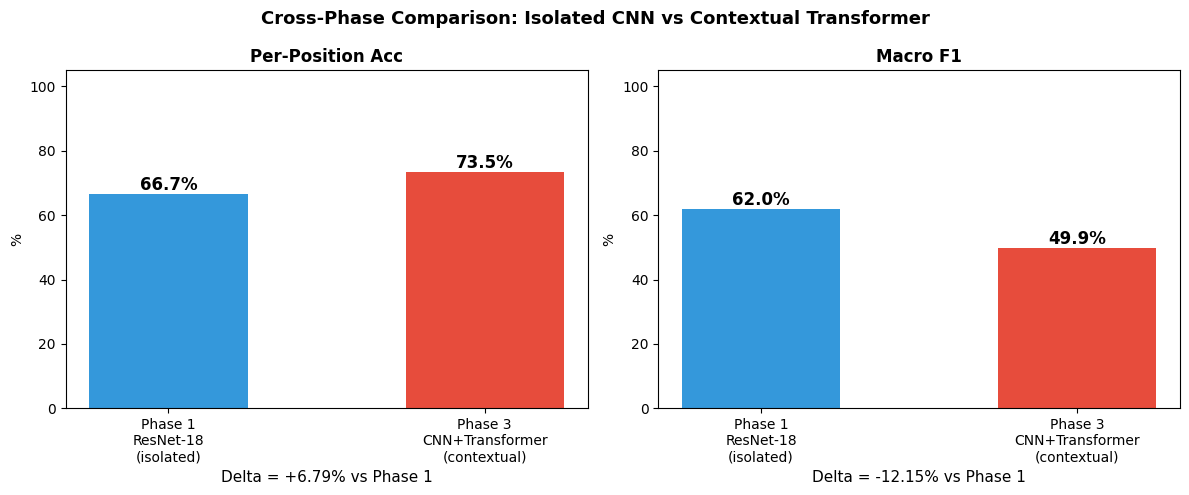

In [19]:
comp = pd.DataFrame({
    'Phase': [
        'Phase 1: ResNet-18 (isolated, per-image)',
        'Phase 3: ResNet-18 + Transformer (contextual)'
    ],
    'Context': ['None - single image', 'Full sequence (learned attention)'],
    'Per-Position Acc': [
        f'{phase1["test_top1"]*100:.2f}%',
        f'{pos_acc*100:.2f}%'
    ],
    'Macro F1': [
        f'{phase1["macro_f1"]*100:.2f}%',
        f'{macro_f1*100:.2f}%'
    ],
    'Sequence Acc': ['N/A', f'{seq_acc*100:.2f}%'],
    'New params': ['~11.7M (fine-tuned)', '~1.76M (transformer only)']
})
print(comp.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
metrics = ['Per-Position Acc', 'Macro F1']
p1_vals = [phase1['test_top1']*100, phase1['macro_f1']*100]
p3_vals = [pos_acc*100,             macro_f1*100]

for ax, metric, p1v, p3v in zip(axes, metrics, p1_vals, p3_vals):
    bars = ax.bar(['Phase 1\nResNet-18\n(isolated)',
                   'Phase 3\nCNN+Transformer\n(contextual)'],
                  [p1v, p3v], color=['#3498db', '#e74c3c'], width=0.5)
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_ylabel('%'); ax.set_ylim(0, 105)
    for bar, val in zip(bars, [p1v, p3v]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
    ax.set_xlabel(f'Delta = {p3v-p1v:+.2f}% vs Phase 1', fontsize=11)

plt.suptitle('Cross-Phase Comparison: Isolated CNN vs Contextual Transformer',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cross_phase_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


# **<span style="color: #c9a84c;">💾 Section 8 - Save Artifacts</span>**

In [22]:
SAVE_DIR = Path('/kaggle/working')

torch.save(best_wts_tr, SAVE_DIR / 'transformer_best.pth')

phase3_results = {
    'model'           : 'CNN + Transformer (ResNet-18 frozen, Glyph2025)',
    'dataset'         : 'Glyph2025 sequences (Franken reading order)',
    'num_classes'     : NUM_CLASSES,
    'per_position_acc': float(pos_acc),
    'sequence_acc'    : float(seq_acc),
    'macro_f1'        : float(macro_f1),
    'weighted_f1'     : float(weighted_f1),
    'macro_precision' : float(macro_prec),
    'macro_recall'    : float(macro_rec),
    'best_val_acc'    : float(best_val_tr),
    'phase1_top1'     : phase1['test_top1'],
    'delta_vs_phase1' : float(pos_acc) - phase1['test_top1']
}

with open(SAVE_DIR / 'phase3_results.json', 'w') as f:
    json.dump(phase3_results, f, indent=2)

print('Files saved to /kaggle/working:')
for f in sorted(SAVE_DIR.glob('*')):
    if f.is_file():
        print(f'  {f.name}  ({f.stat().st_size/1024:.0f} KB)')

print()
print('=' * 62)
print('  PHASE 3 COMPLETE')
print('=' * 62)
print(f'  Phase 1 ResNet-18 (isolated) : {phase1["test_top1"]*100:.2f}%')
print(f'  Phase 3 CNN+Transformer      : {pos_acc*100:.2f}%')
print(f'  Delta                        : {(pos_acc-phase1["test_top1"])*100:+.2f}%')
print(f'  Sequence accuracy            : {seq_acc*100:.2f}%')
print('=' * 62)


Files saved to /kaggle/working:
  cross_phase_comparison.png  (65 KB)
  idx_to_label.json  (3 KB)
  label_map.json  (2 KB)
  phase3_results.json  (0 KB)
  transformer_attention.png  (168 KB)
  transformer_best.pth  (6931 KB)
  transformer_training_curves.png  (142 KB)

  PHASE 3 COMPLETE
  Phase 1 ResNet-18 (isolated) : 66.72%
  Phase 3 CNN+Transformer      : 73.51%
  Delta                        : +6.79%
  Sequence accuracy            : 0.00%
